<a href="https://colab.research.google.com/github/lovita11/DataScience/blob/main/Pertemuan5_LovitaPrasetia_250401020061.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# ── 1. LOAD & INSPECT DATASET ──────────────────────────────────────────
#Immport Data
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, matplotlib.gridspec as gridspec
import seaborn as sns
df = sns.load_dataset('tips')
print(df.shape, df.dtypes)
print(df.describe().round(2))

(244, 7) total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object
       total_bill     tip    size
count      244.00  244.00  244.00
mean        19.79    3.00    2.57
std          8.90    1.38    0.95
min          3.07    1.00    1.00
25%         13.35    2.00    2.00
50%         17.80    2.90    2.00
75%         24.13    3.56    3.00
max         50.81   10.00    6.00


/tmp/ipykernel_1415/1091339935.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_by_day = df.groupby('day')['total_bill'].mean()
/tmp/ipykernel_1415/1091339935.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


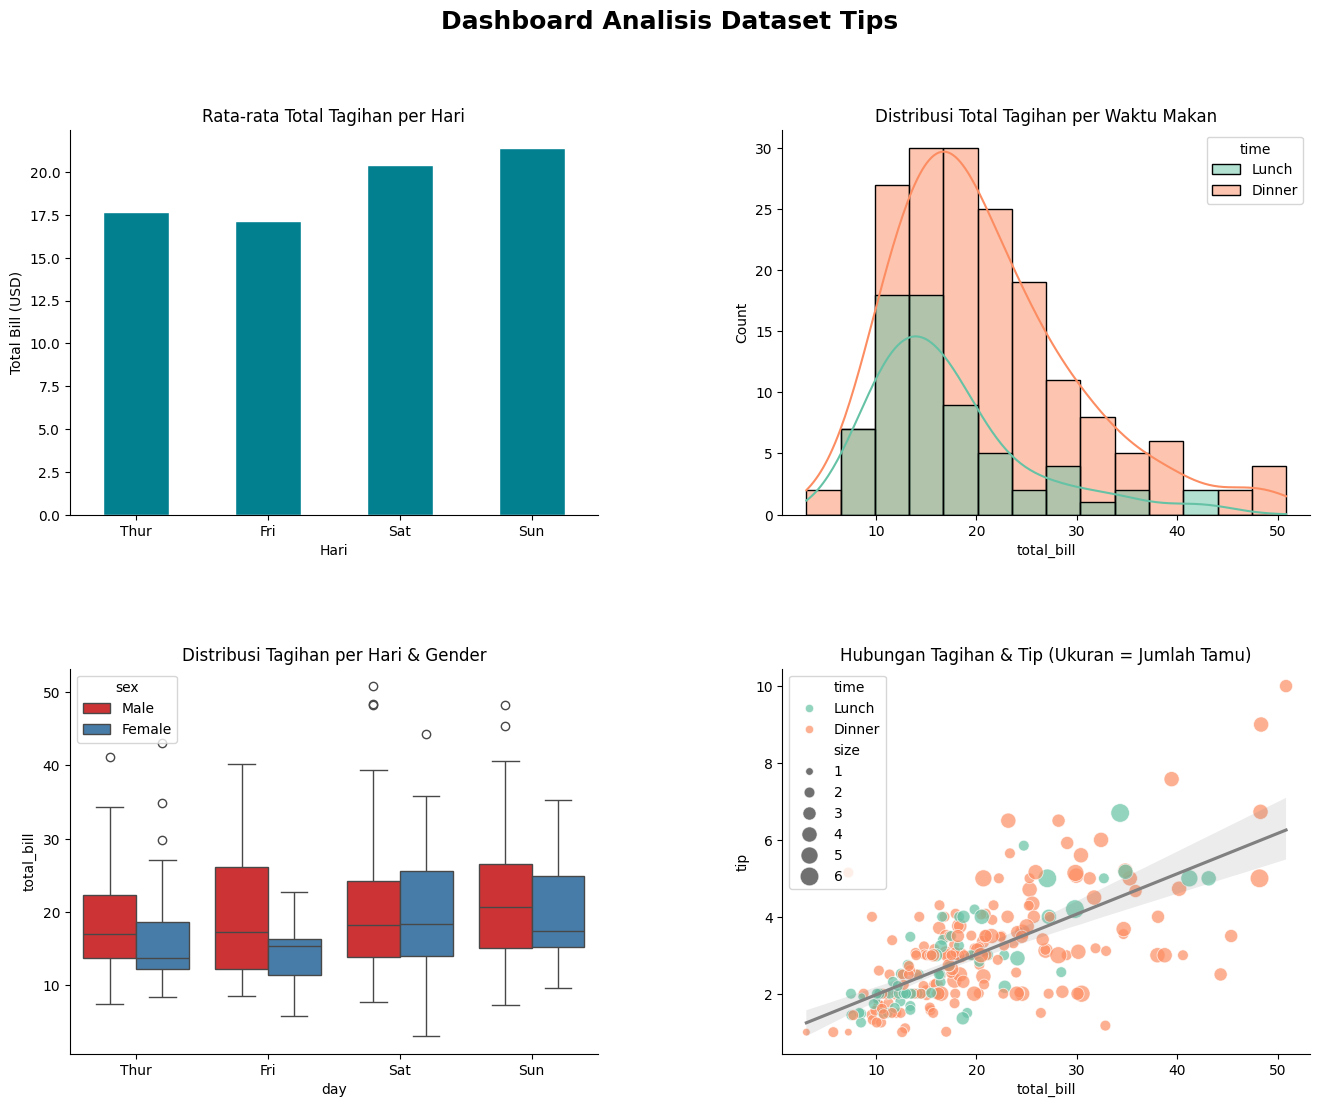

<Figure size 640x480 with 0 Axes>

Dashboard tersimpan sebagai dashboard_tips.png


In [13]:
# ── 2. SETUP FIGURE LAYOUT ─────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
fig.suptitle('Dashboard Analisis Dataset Tips',
fontsize=18, fontweight='bold', y=0.98)
# Grid 2 x 2 subplot
gs = gridspec.GridSpec(2, 2, figure=fig,
hspace=0.4, wspace=0.35)
ax1 = fig.add_subplot(gs[0, 0]) # kiri atas
ax2 = fig.add_subplot(gs[0, 1]) # kanan atas
ax3 = fig.add_subplot(gs[1, 0]) # kiri bawah
ax4 = fig.add_subplot(gs[1, 1]) # kanan bawah

# ── 3. GRAFIK 1: Bar Chart ─────────────────────────────────────────────
avg_by_day = df.groupby('day')['total_bill'].mean()
avg_by_day.plot(kind='bar', ax=ax1, color='#028090',
edgecolor='white')
ax1.set_title('Rata-rata Total Tagihan per Hari')
ax1.set_xlabel('Hari'); ax1.set_ylabel('Total Bill (USD)')
ax1.tick_params(axis='x', rotation=0)
ax1.spines[['top','right']].set_visible(False)

# ── 4. GRAFIK 2: Histogram + KDE ───────────────────────────────────────
sns.histplot(data=df, x='total_bill', hue='time',
kde=True, palette='Set2', ax=ax2)
ax2.set_title('Distribusi Total Tagihan per Waktu Makan')
ax2.spines[['top','right']].set_visible(False)

# ── 5. GRAFIK 3: Boxplot ───────────────────────────────────────────────
sns.boxplot(data=df, x='day', y='total_bill',
hue='sex', palette='Set1', ax=ax3)
ax3.set_title('Distribusi Tagihan per Hari & Gender')
ax3.spines[['top','right']].set_visible(False)

# ── 6. GRAFIK 4: Scatter Plot ──────────────────────────────────────────
sns.scatterplot(data=df, x='total_bill', y='tip',
hue='time', size='size', sizes=(30,180),
palette='Set2', alpha=0.7, ax=ax4)
sns.regplot(data=df, x='total_bill', y='tip',
scatter=False, color='gray', ax=ax4)
ax4.set_title('Hubungan Tagihan & Tip (Ukuran = Jumlah Tamu)')
ax4.spines[['top','right']].set_visible(False)

plt.tight_layout()
fig.savefig('tipsse.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 7. EKSPOR ──────────────────────────────────────────────────────────
plt.savefig('dashboard_tips.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard tersimpan sebagai dashboard_tips.png')


# **ANALISIS CHARTS**
1. **BAR CHART** — Rata-rata Total Tagihan per Hari

What?
Grafik menunjukkan rata-rata total tagihan pelanggan dari hari Kamis sampai Minggu. Nilai rata-rata tagihan terendah terjadi pada hari Jumat sekitar 17 USD, sedangkan tertinggi terjadi pada hari Minggu sekitar 21–22 USD. Hari Sabtu juga menunjukkan rata-rata tagihan yang cukup tinggi dibanding hari kerja.

So what?

Data ini menunjukkan bahwa pelanggan cenderung mengeluarkan lebih banyak uang pada akhir pekan dibandingkan hari kerja. Aktivitas restoran meningkat pada hari Sabtu dan Minggu karena lebih banyak pelanggan datang untuk makan bersama keluarga atau teman.

Now what?

Restoran dapat menambah persediaan makanan, jumlah karyawan, dan meningkatkan pelayanan pada akhir pekan untuk mengantisipasi lonjakan pelanggan. Strategi promosi khusus weekday juga dapat dilakukan untuk meningkatkan transaksi pada hari Kamis dan Jumat.


2. **HISTOGRAM** — Distribusi Total Tagihan Berdasarkan Waktu Makan

What?

Histogram menunjukkan distribusi total tagihan pelanggan pada waktu makan siang (Lunch) dan malam (Dinner). Sebagian besar transaksi berada pada kisaran 10–20 USD. Transaksi makan malam memiliki jumlah lebih banyak dan variasi tagihan yang lebih tinggi dibanding makan siang.

So what?

Hal ini menunjukkan bahwa pelanggan saat makan malam cenderung memesan lebih banyak makanan atau datang dalam kelompok yang lebih besar. Dinner menjadi waktu dengan kontribusi pendapatan terbesar bagi restoran.

Now what?

Restoran dapat memfokuskan promosi premium atau menu spesial pada jam makan malam. Selain itu, pengaturan staf dan stok bahan makanan perlu diperkuat pada waktu dinner agar pelayanan tetap optimal.


3. **BOXPLOT** — Distribusi Tagihan Berdasarkan Hari dan Gender

What?

Boxplot menunjukkan distribusi total tagihan berdasarkan hari dan jenis kelamin pelanggan. Terlihat adanya beberapa outlier dengan nilai tagihan sangat tinggi, terutama pada akhir pekan. Variasi tagihan pelanggan laki-laki dan perempuan tidak terlalu jauh berbeda.

So what?

Adanya outlier menunjukkan bahwa terdapat pelanggan dengan transaksi besar yang dapat meningkatkan pendapatan restoran secara signifikan. Akhir pekan menjadi waktu dengan variasi pengeluaran pelanggan yang lebih tinggi.

Now what?

Restoran dapat menyediakan paket keluarga atau menu grup pada akhir pekan untuk menarik pelanggan dengan transaksi besar. Analisis lebih lanjut terhadap pelanggan dengan pengeluaran tinggi juga dapat membantu strategi pemasaran.


4. **SCATTER PLOT** — Hubungan Total Tagihan dan Tip

What?

Scatter plot menunjukkan hubungan positif antara total tagihan dan jumlah tip yang diberikan pelanggan. Semakin besar total tagihan, maka tip yang diberikan juga cenderung meningkat.

So what?

Hal ini menunjukkan bahwa pelanggan yang melakukan transaksi besar biasanya memberikan tip lebih tinggi. Faktor jumlah tamu juga mempengaruhi besarnya tagihan dan tip.

Now what?

Restoran dapat meningkatkan kualitas pelayanan kepada pelanggan dengan transaksi besar untuk meningkatkan kepuasan pelanggan dan potensi tip bagi pelayan. Selain itu, restoran dapat menyediakan pelayanan khusus untuk grup besar agar pengalaman pelanggan lebih baik.